# Astigmatic Beam Shaping — Progressive Constraint Tightening

**Problem**: Focus a circular Gaussian beam (λ=800 nm, w₀=1.2 mm) to an astigmatic
waist using a fixed 3-lens combination (**Spherical + CylX + CylY**).

| Parameter | Value |
|-----------|-------|
| Wavelength λ | 800 nm |
| Input waist w₀ | 1.2 mm (circular) |
| Target position z | 500 mm |
| Target w_x | 200 µm |
| Target w_y | 750 µm |
| Waist position tolerance | \|Δz\| / z_R ≤ 0.1 |

**Lens types**

| Type | x-axis | y-axis |
|------|--------|--------|
| `spherical` | ThinLens(f) | ThinLens(f) |
| `cyl_x` | ThinLens(f) | identity |
| `cyl_y` | identity | ThinLens(f) |

**Strategy**: Progressive constraint tightening.

| Step | Constraints |
|------|-------------|
| 1 | f ∈ (−10000, 10000) mm, z ≤ 480 mm, no sep. |
| 2 | + sep ≥ 20 mm, Δf = 5 mm |
| 3 | + \|f\| ∈ [30, 1000] mm |

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from gbeampro import GaussBeam, OpticalSystem, Propagation
from gbeampro.optimize import waist_operands, optimize_astigmatic, build_xy_systems
import gbeampro.plot as gplot
import gbeampro.analysis as ga
import gbeampro
print('gbeampro version:', gbeampro.__version__)

gbeampro version: 2.0.0


## Problem Setup

In [2]:
WL        = 0.800   # µm
W0        = 1.2     # mm
Z_TARGET  = 500.0   # mm
WX_TARGET = 0.200   # mm
WY_TARGET = 0.750   # mm
WAIST_TOL_ZR = 0.1  # PASS if |Δz| / z_R ≤ this

LENS_TYPES = ['spherical', 'cyl_x', 'cyl_y']

beam = GaussBeam.from_waist(wl_um=WL, w0_mm=W0)
print(beam)

traj0 = OpticalSystem().add(Propagation(Z_TARGET)).trace(beam, dz=1.0)
print(f'\nWithout optics at z={Z_TARGET} mm:  w = {traj0[-1].w_mm*1e3:.1f} µm')
print(f'Targets:  w_x = {WX_TARGET*1e3:.0f} µm,  w_y = {WY_TARGET*1e3:.0f} µm')

operands = waist_operands(
    z_mm=Z_TARGET, wx_mm=WX_TARGET, wy_mm=WY_TARGET,
    size_weight=1.0,
    curvature_weight_x=1.0,
    curvature_weight_y=1.0,
)
print(f'\nMerit function operands:')
for op in operands:
    print(f'  {op.type:<4}  target={op.target:.4g}  weight={op.weight:.3g}')

GaussBeam(wl_um=0.8, n=1.0, z_mm=0.00000, R_mm=inf, w_mm=1.20000)
  q = 0.00000e+00-5.65487e+03j  theta = 0.2122 mrad

Without optics at z=500.0 mm:  w = 1204.7 µm
Targets:  w_x = 200 µm,  w_y = 750 µm

Merit function operands:
  wx    target=0.2  weight=1
  wy    target=0.75  weight=1
  cvx   target=0  weight=1
  cvy   target=0  weight=1


## Helper Functions

In [3]:
def print_specs(result):
    print(f"{'#':>2}  {'Type':<12}  {'z (mm)':>10}  {'f (mm)':>10}  {'|f| (mm)':>10}")
    print('   ' + '-' * 48)
    for i, s in enumerate(result.specs, 1):
        ftype = 'conv.' if s['f_mm'] > 0 else 'div.'
        print(f"{i:>2}  {s['type']:<12}  {s['z_mm']:>10.2f}  {s['f_mm']:>10.2f}  "
              f"{abs(s['f_mm']):>10.2f}  ({ftype})")
    if len(result.specs) > 1:
        seps = [result.specs[i+1]['z_mm'] - result.specs[i]['z_mm']
                for i in range(len(result.specs)-1)]
        print(f'  separations: {[f"{d:.1f} mm" for d in seps]}')

def verify_waists(result):
    Z_EXTRA = Z_TARGET + 200.0
    sx, sy = build_xy_systems(beam, result.specs, Z_EXTRA)
    for axis, sys_, target in [('x', sx, WX_TARGET), ('y', sy, WY_TARGET)]:
        waists = ga.find_waists(sys_.trace(beam, dz=1.0))
        print(f'{axis}-axis:')
        for w in waists:
            zr = ga.rayleigh_range(w)
            dz_over_zr = (w.z_mm - Z_TARGET) / zr
            ok = 'PASS' if abs(dz_over_zr) <= WAIST_TOL_ZR else 'FAIL'
            print(f'  z={w.z_mm:.1f} mm (Δz={w.z_mm-Z_TARGET:+.1f}, Δz/z_R={dz_over_zr:+.3f})  '
                  f'w₀={w.w_mm*1e3:.2f} µm  2z_R={2*zr:.1f} mm  [{ok}]')
        if not waists:
            print('  (none found in range)')

def plot_result(result, title):
    Z_EXTRA = Z_TARGET + 100.0
    sx, sy = build_xy_systems(beam, result.specs, Z_EXTRA)
    traj_x = sx.trace(beam, dz=1.0)
    traj_y = sy.trace(beam, dz=1.0)
    fig, ax = plt.subplots(figsize=(12, 4))
    gplot.plot_system(sx, traj_x, ax, label=f'x-axis  ({WX_TARGET*1e3:.0f} µm)')
    gplot.plot_system(sy, traj_y, ax, label=f'y-axis  ({WY_TARGET*1e3:.0f} µm)')
    ax.axvline(Z_TARGET, color='k', ls=':', lw=1.2)
    ax.scatter([Z_TARGET, Z_TARGET], [WX_TARGET*1e3, WY_TARGET*1e3],
               color='k', zorder=6, s=60, label='targets')
    ax.set_title(title)
    plt.tight_layout()

## Step 1: Theoretical Baseline

Any focal length allowed, lenses placed anywhere in [0, 480 mm] (20 mm margin before target).
No separation constraint.

In [4]:
r1 = optimize_astigmatic(
    beam, LENS_TYPES, operands,
    f_bounds=(-1000, 1000),
    z_max_mm=450.0,
    min_lens_sep_mm=0.0,
    algorithm='de',
    maxiter=2000, popsize=20, seed=42,
)
print(f'merit = {r1.merit:.2e}')
print_specs(r1)

merit = 2.21e-01
 #  Type              z (mm)      f (mm)    |f| (mm)
   ------------------------------------------------
 1  spherical           0.00     1000.00     1000.00  (conv.)
 2  cyl_x               5.19     1000.00     1000.00  (conv.)
 3  cyl_y             377.61     -652.19      652.19  (div.)
  separations: ['5.2 mm', '372.4 mm']


x-axis:
  z=500.8 mm (Δz=+0.8, Δz/z_R=+0.017)  w₀=105.98 µm  2z_R=88.2 mm  [PASS]
y-axis:
  z=500.8 mm (Δz=+0.8, Δz/z_R=+0.000)  w₀=750.00 µm  2z_R=4417.9 mm  [PASS]


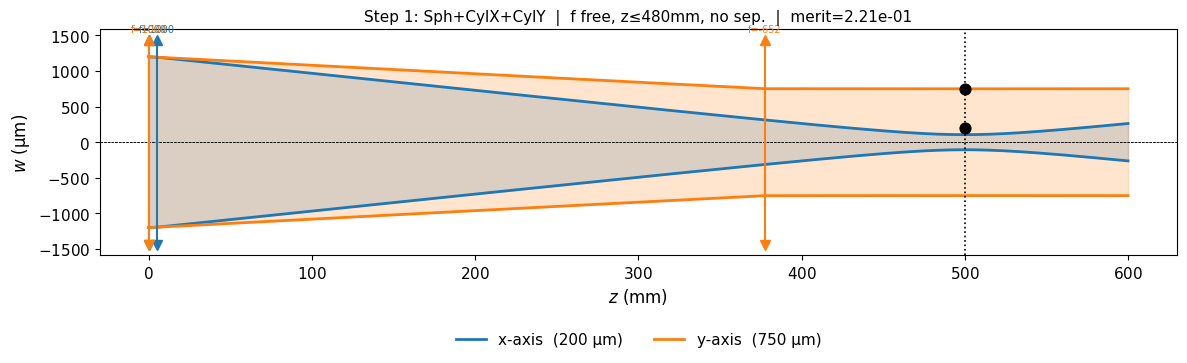

In [5]:
plot_result(r1,
    f'Step 1: Sph+CylX+CylY  |  f free, z≤480mm, no sep.  |  merit={r1.merit:.2e}')
verify_waists(r1)

## Step 2: Add Mechanical + Catalog Discretization

- **Lens separation ≥ 20 mm**
- **Δf = 5 mm** (catalog discretization)

In [6]:
r2 = optimize_astigmatic(
    beam, LENS_TYPES, operands,
    f_bounds=(-1000, 1000),
    f_step_mm=5.0,
    z_max_mm=450.0,
    min_lens_sep_mm=20.0,
    algorithm='de',
    maxiter=2000, popsize=20, seed=42,
)
print(f'merit = {r2.merit:.2e}')
print_specs(r2)

merit = 1.05e-01
 #  Type              z (mm)      f (mm)    |f| (mm)
   ------------------------------------------------
 1  spherical           0.00      255.00      255.00  (conv.)
 2  cyl_x              99.10     -250.00      250.00  (div.)
 3  cyl_y             119.10     -135.00      135.00  (div.)
  separations: ['99.1 mm', '20.0 mm']


x-axis:
  z=501.0 mm (Δz=+1.0, Δz/z_R=+0.013)  w₀=141.80 µm  2z_R=157.9 mm  [PASS]
y-axis:
  z=119.1 mm (Δz=-380.9, Δz/z_R=-0.237)  w₀=640.02 µm  2z_R=3217.2 mm  [FAIL]


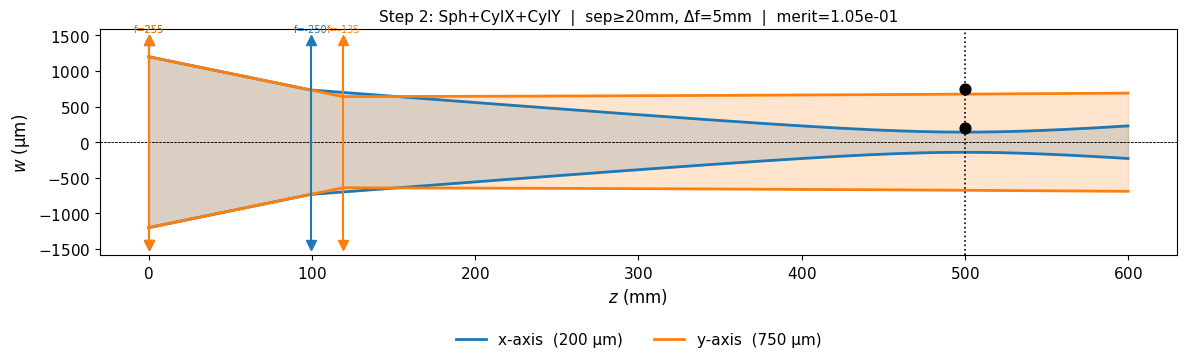

In [7]:
plot_result(r2,
    f'Step 2: Sph+CylX+CylY  |  sep≥20mm, Δf=5mm  |  merit={r2.merit:.2e}')
verify_waists(r2)

## Step 3: Add Focal Length Range Constraint

Further restrict to **|f| ∈ [30, 1000] mm** — standard catalog range.
All Step 2 constraints remain active.

In [8]:
r3 = optimize_astigmatic(
    beam, LENS_TYPES, operands,
    f_abs_bounds=(30, 600),
    f_step_mm=5.0,
    z_max_mm=450.0,
    min_lens_sep_mm=20.0,
    algorithm='de',
    maxiter=2000, popsize=20, seed=42,
)
print(f'merit = {r3.merit:.2e}')
print_specs(r3)

merit = 9.14e-02
 #  Type              z (mm)      f (mm)    |f| (mm)
   ------------------------------------------------
 1  spherical           0.00      170.00      170.00  (conv.)
 2  cyl_x              60.04     -145.00      145.00  (div.)
 3  cyl_y              80.04      -90.00       90.00  (div.)
  separations: ['60.0 mm', '20.0 mm']


x-axis:
  z=501.0 mm (Δz=+1.0, Δz/z_R=+0.012)  w₀=147.03 µm  2z_R=169.8 mm  [PASS]
y-axis:
  z=80.0 mm (Δz=-420.0, Δz/z_R=-0.265)  w₀=635.23 µm  2z_R=3169.2 mm  [FAIL]


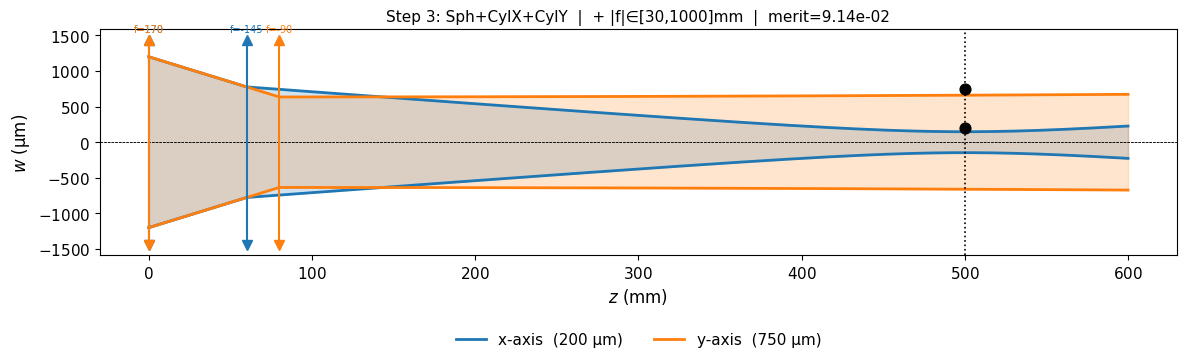

In [9]:
plot_result(r3,
    f'Step 3: Sph+CylX+CylY  |  + |f|∈[30,1000]mm  |  merit={r3.merit:.2e}')
verify_waists(r3)

## Summary

In [10]:
print(f"{'Step':<6}  {'Constraints':<50}  {'merit':>10}")
print('-' * 70)
for step, desc, res in [
    ('1', 'f free, z≤480mm, no sep.',                        r1),
    ('2', '+ sep≥20mm, Δf=5mm',                              r2),
    ('3', '+ |f|∈[30,1000]mm',                               r3),
]:
    print(f'{step:<6}  {desc:<50}  {res.merit:>10.2e}')

print()
print('Step 3 (most realistic):')
sx3, sy3 = build_xy_systems(beam, r3.specs, Z_TARGET + 200)
print('=== x-axis ===')
print(sx3.summary(beam))
print('=== y-axis ===')
print(sy3.summary(beam))

Step    Constraints                                              merit
----------------------------------------------------------------------
1       f free, z≤480mm, no sep.                              2.21e-01
2       + sep≥20mm, Δf=5mm                                    1.05e-01
3       + |f|∈[30,1000]mm                                     9.14e-02

Step 3 (most realistic):
=== x-axis ===


OpticalSystem trace  [wl=0.8 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1200.00         inf      212.21
   1  Propagation             0.000    1200.00   1.103e+19      212.21
   2  ThinLens                0.000    1200.00  -1.700e+02      212.21
   3  Propagation            60.042     776.28  -1.100e+02      328.04
   4  ThinLens               60.042     776.28  -4.564e+02      328.04
   5  Propagation            80.042     742.29  -4.372e+02      343.06
   6  Propagation           700.000     376.15   2.359e+02      676.98
Beam waists:  z=500.111 mm (2w0=294.0 um)
=== y-axis ===


OpticalSystem trace  [wl=0.8 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1200.00         inf      212.21
   1  Propagation             0.000    1200.00   1.103e+19      212.21
   2  ThinLens                0.000    1200.00  -1.700e+02      212.21
   3  Propagation            60.042     776.28  -1.100e+02      328.04
   4  Propagation            80.042     635.23  -9.009e+01      400.88
   5  ThinLens               80.042     635.23   8.542e+04      400.88
   6  Propagation           700.000     686.41   4.514e+03      370.99
Beam waists:  z=80.042 mm (2w0=1270.5 um)


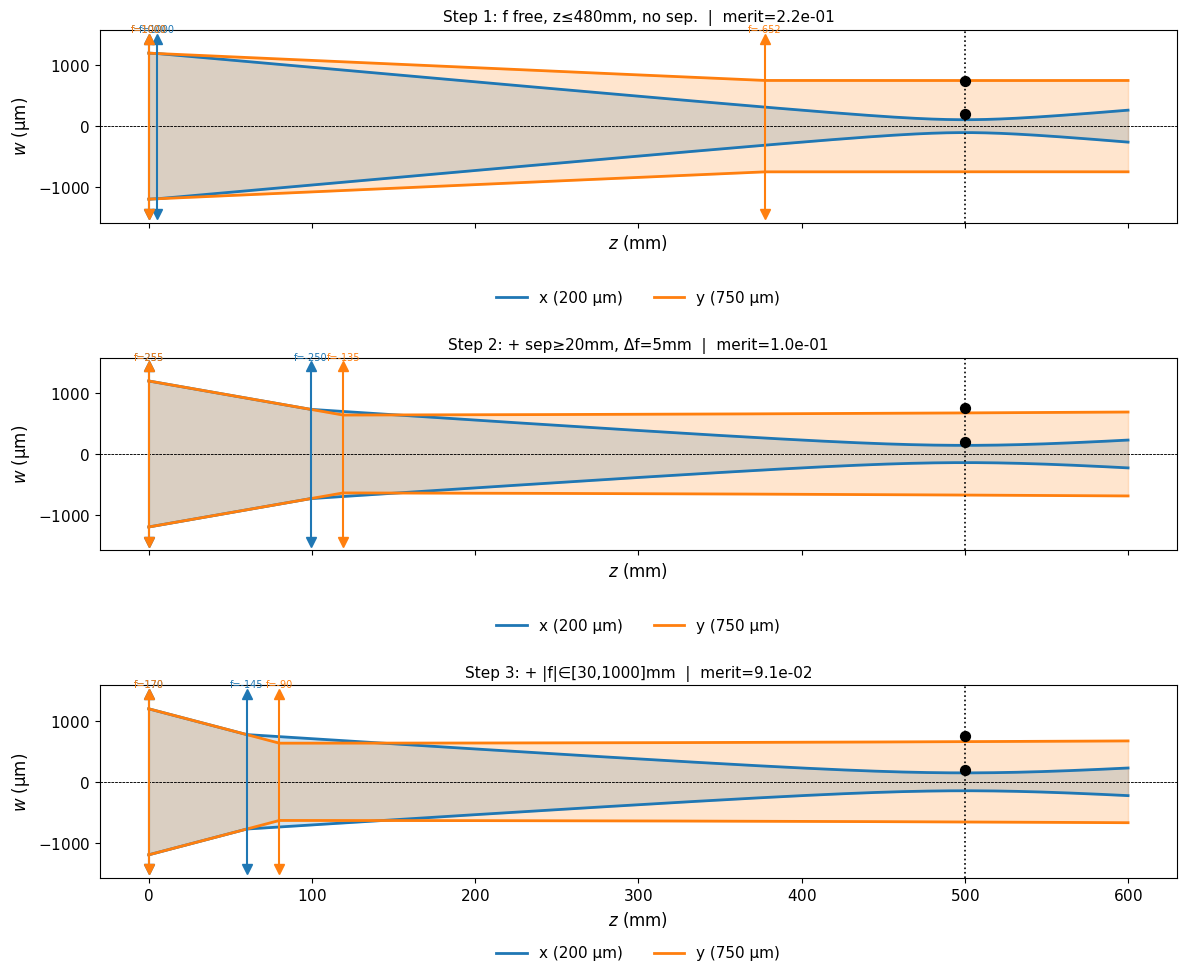

In [11]:
Z_EXTRA = Z_TARGET + 100.0
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, (res, label) in zip(axes, [
    (r1, 'Step 1: f free, z≤480mm, no sep.'),
    (r2, 'Step 2: + sep≥20mm, Δf=5mm'),
    (r3, 'Step 3: + |f|∈[30,1000]mm'),
]):
    sx, sy = build_xy_systems(beam, res.specs, Z_EXTRA)
    gplot.plot_system(sx, sx.trace(beam, dz=1.0), ax, label=f'x ({WX_TARGET*1e3:.0f} µm)')
    gplot.plot_system(sy, sy.trace(beam, dz=1.0), ax, label=f'y ({WY_TARGET*1e3:.0f} µm)')
    ax.axvline(Z_TARGET, color='k', ls=':', lw=1.2)
    ax.scatter([Z_TARGET, Z_TARGET], [WX_TARGET*1e3, WY_TARGET*1e3],
               color='k', zorder=6, s=50)
    ax.set_title(f'{label}  |  merit={res.merit:.1e}')

plt.tight_layout()